## Setting up libraties, device, and seed

In [1]:
# imports
import numpy as np
import pandas as pd
import torch

import torch.nn as nn
import torch.optim as optim

import glob
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score


In [2]:
%matplotlib inline
# САНЯ я єбу чи то треба, каже що в notebooці воно гарніше виглядатиме, якщо ти щось схоже робив то видали нахуй
# Це тіпа декоратор і фотки зразу під низ вставляє, але я хз
# for images output. In some cases(old version of notebook/ opening file exactly in GitHub) photos output from notebook might be broken. 

In [3]:
#Setting devices for time efficiency
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.backends.mps.is_available():
    device = torch.device("mps")


#Seed to ensure reproducibility
def set_seed(seed=123):
    import random, numpy as np, torch, os
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(288)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ["PYTHONHASHSEED"] = str(seed)

set_seed(42)

## Data handling

In [4]:
# csv read
df = pd.read_csv('data/AirQualityUCI.csv', sep=";")
df

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,10/03/2004,18.00.00,"2,6",1360.0,150.0,"11,9",1046.0,166.0,1056.0,113.0,1692.0,1268.0,"13,6","48,9","0,7578",NaN,NaN
1,10/03/2004,19.00.00,2,1292.0,112.0,"9,4",955.0,103.0,1174.0,92.0,1559.0,972.0,"13,3","47,7","0,7255",NaN,NaN
2,10/03/2004,20.00.00,"2,2",1402.0,88.0,"9,0",939.0,131.0,1140.0,114.0,1555.0,1074.0,"11,9","54,0","0,7502",NaN,NaN
3,10/03/2004,21.00.00,"2,2",1376.0,80.0,"9,2",948.0,172.0,1092.0,122.0,1584.0,1203.0,"11,0","60,0","0,7867",NaN,NaN
4,10/03/2004,22.00.00,"1,6",1272.0,51.0,"6,5",836.0,131.0,1205.0,116.0,1490.0,1110.0,"11,2","59,6","0,7888",NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9466,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9467,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9468,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9469,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# type casting

df['CO(GT)'] = df['CO(GT)'].str.replace(',', '.').astype(float)
df['C6H6(GT)'] = df['C6H6(GT)'].str.replace(',', '.').astype(float)
df['T'] = df['T'].str.replace(',', '.').astype(float)
df['RH'] = df['RH'].str.replace(',', '.').astype(float)
df['AH'] = df['AH'].str.replace(',', '.').astype(float)

In [6]:
# dropping null values and unrelevant columns
df.drop(inplace=True, columns=['Unnamed: 15', 'Unnamed: 16', "NMHC(GT)"])
df.dropna(inplace=True)

# drop rows where T equals -200
df.drop(df[df['T'] == -200].index, inplace=True)

print(df.describe())

# interpolate null values
df.replace(-200, np.nan, inplace=True)

columns_to_interpolate = [
    'CO(GT)', 'PT08.S1(CO)', 'C6H6(GT)', 'PT08.S2(NMHC)',
    'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)',
    'PT08.S5(O3)', 'T', 'RH', 'AH'
]

df[columns_to_interpolate] = df[columns_to_interpolate].interpolate(method='linear')

            CO(GT)  PT08.S1(CO)     C6H6(GT)  PT08.S2(NMHC)      NOx(GT)  \
count  8991.000000  8991.000000  8991.000000    8991.000000  8991.000000   
mean    -34.897053  1099.833166    10.083105     939.153376   163.745078   
std      78.202259   217.080037     7.449820     266.831429   252.090703   
min    -200.000000   647.000000     0.100000     383.000000  -200.000000   
25%       0.600000   937.000000     4.400000     734.500000    49.000000   
50%       1.500000  1063.000000     8.200000     909.000000   140.000000   
75%       2.600000  1231.000000    14.000000    1116.000000   280.000000   
max      11.900000  2040.000000    63.700000    2214.000000  1479.000000   

       PT08.S3(NOx)      NO2(GT)  PT08.S4(NO2)  PT08.S5(O3)            T  \
count   8991.000000  8991.000000   8991.000000  8991.000000  8991.000000   
mean     835.493605    56.666555   1456.264598  1022.906128    18.317829   
std      256.817320   126.910900    346.206794   398.484288     8.832116   
min      32

Splitting Data

In [7]:
X=df
X=X.drop(columns="Time")
X=X.drop(columns="T")
X=X.drop(columns="Date")
X=X.drop(columns="AH")


y=df["T"]


X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.10, random_state=228
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.111, random_state=228
)

## Exploratory Data Analysis (EDA)

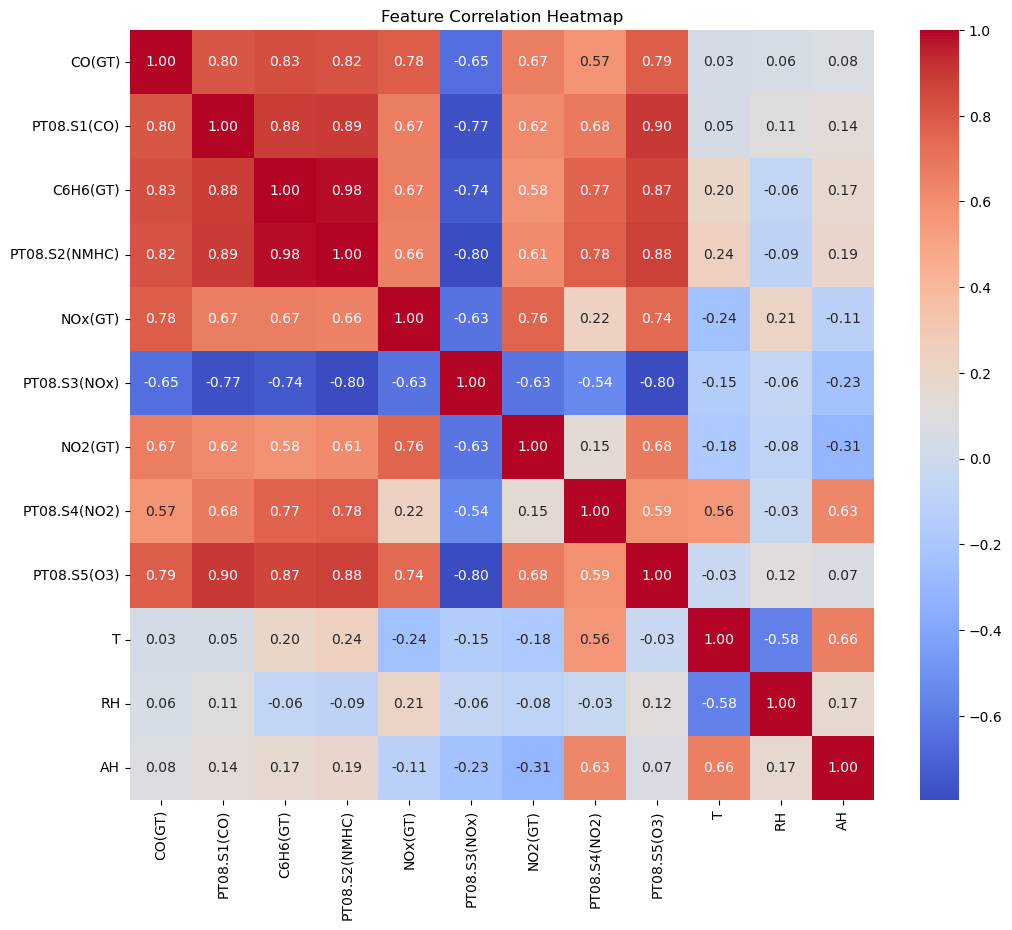

<Figure size 1200x1000 with 0 Axes>

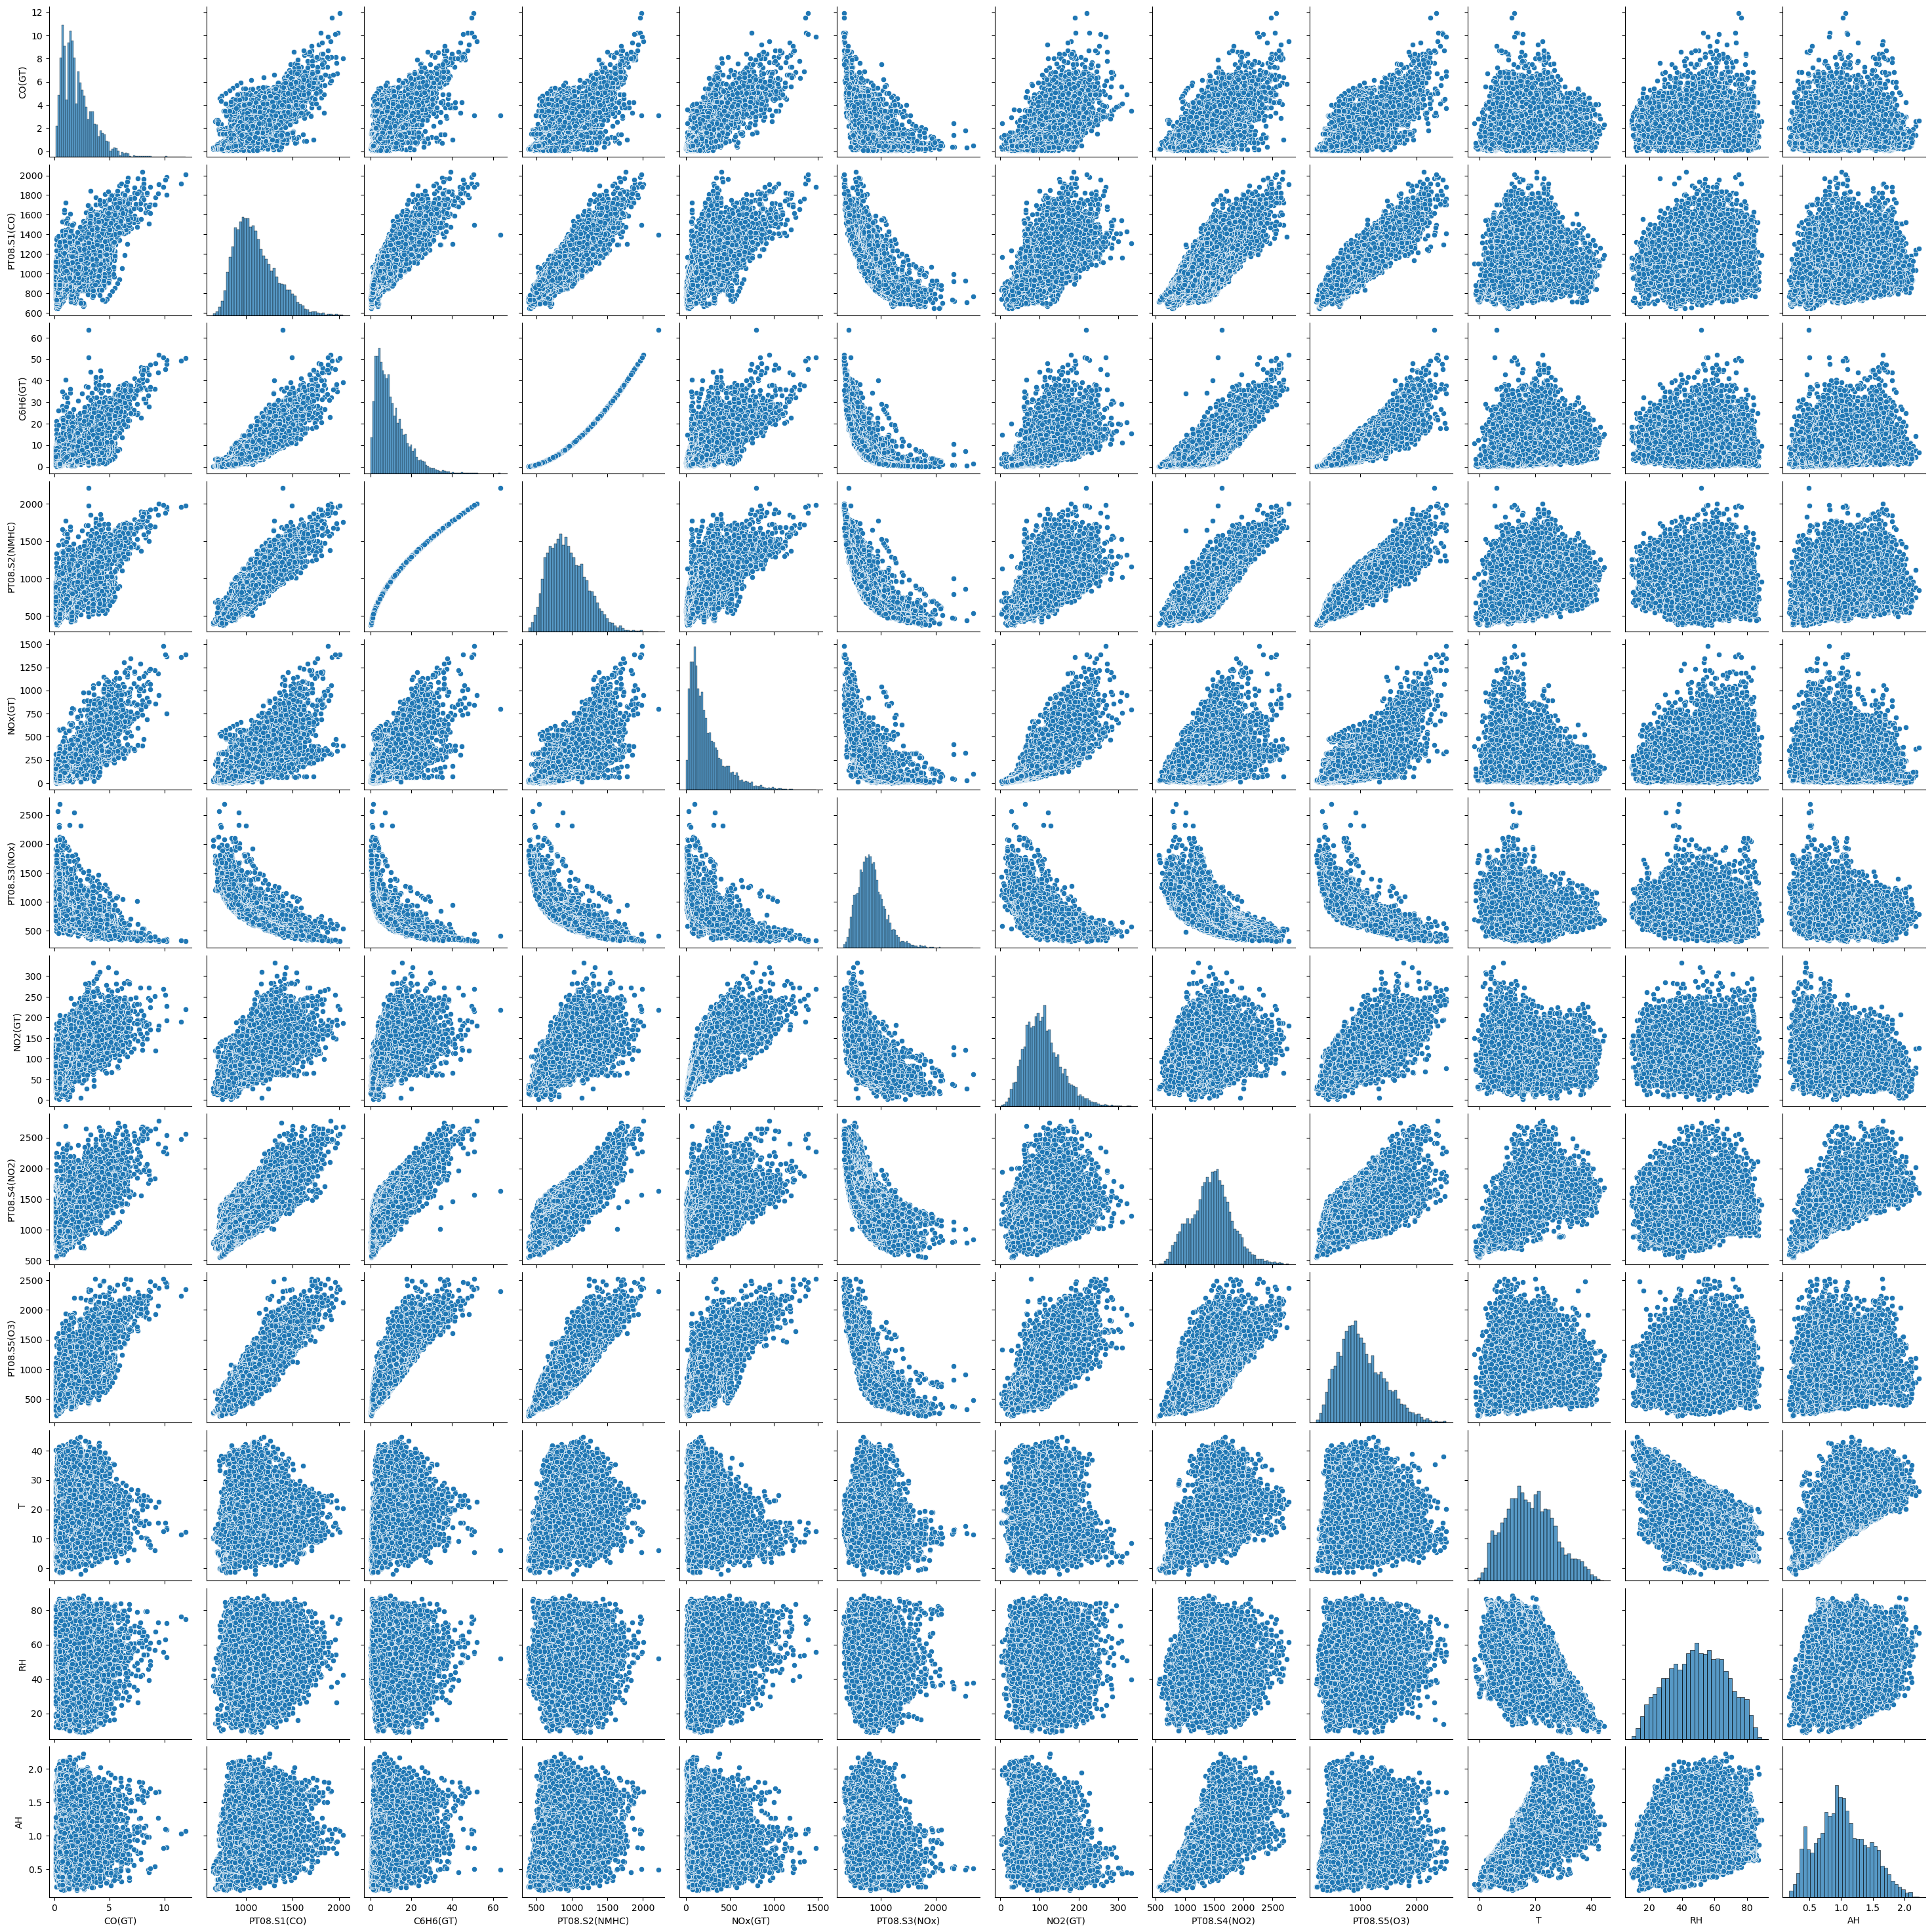

In [8]:
correlation_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

cols_to_check = ['T', 'CO(GT)', 'NOx(GT)', 'C6H6(GT)']
plt.figure(figsize=(12, 10))
sns.pairplot(df)
plt.show()

In [10]:
y = df['T']

X = df.drop(columns=['T', 'Date', 'Time', 'Datetime'], errors='ignore')
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      T   R-squared:                       0.932
Model:                            OLS   Adj. R-squared:                  0.931
Method:                 Least Squares   F-statistic:                 1.111e+04
Date:                Tue, 04 Aug 2026   Prob (F-statistic):               0.00
Time:                        12:03:20   Log-Likelihood:                -20288.
No. Observations:                8991   AIC:                         4.060e+04
Df Residuals:                    8979   BIC:                         4.069e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             8.2610      0.613     13.483

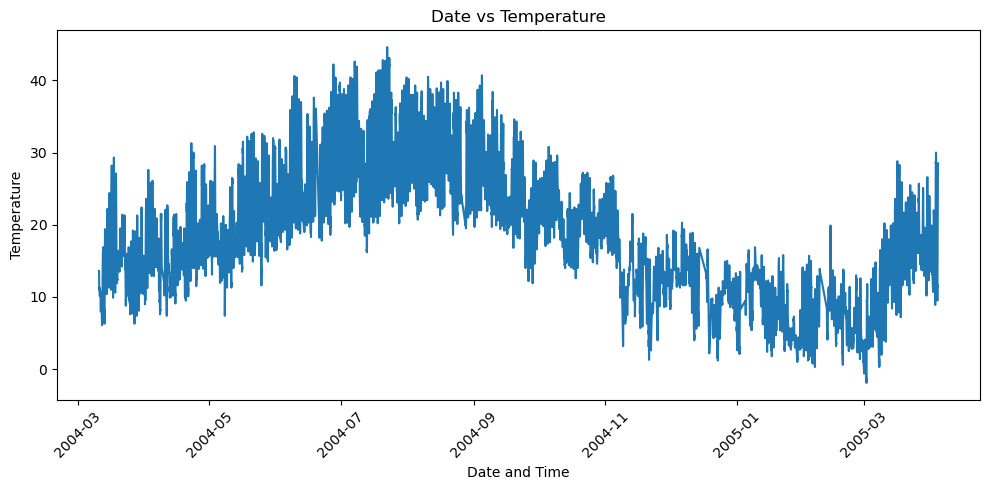

In [11]:
# temperature to datetime visualization
x = df['Date']
y= df['T']

df['Time'] = df['Time'].str.replace('.', ':')
df['Datetime'] = df['Date'] + ' ' + df['Time']
df['Datetime'] = pd.to_datetime(df['Datetime'], dayfirst=True)

plt.figure(figsize=(10, 5))
plt.plot(df['Datetime'], df['T'])
plt.title('Date vs Temperature')
plt.xlabel('Date and Time')
plt.ylabel('Temperature')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
df.drop(columns=['Datetime'], inplace=True)

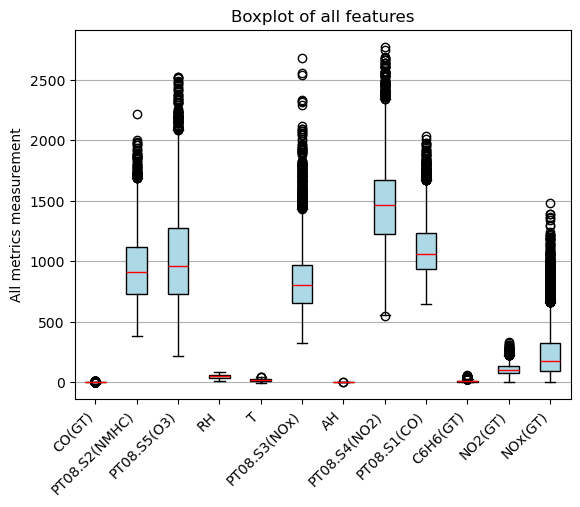

In [12]:
# Histogram for understanding necessity of normalization, test for outliers

features_histogram = list(set(df.columns.tolist()) - set(["Date", "Time"]))

fig, ax = plt.subplots()
ax.boxplot(df[features_histogram], medianprops=dict(color="r"),patch_artist=True,  boxprops={'facecolor': '#ADD8E6'},labels=features_histogram)
# ax.violinplot(df[features_histogram])

ax.grid(axis='y')
plt.xticks(rotation=45, ha="right")
ax.set_title("Boxplot of all features")
ax.set_ylabel("All metrics measurement")


plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_43960\3233121270.py:12: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



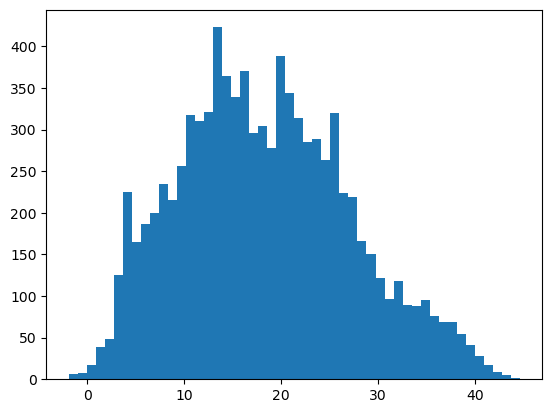

In [13]:
#Temperature distribution

import plotly.figure_factory as ff

fig, ax = plt.subplots()
x1=df["T"]


ax.hist(x1,
    bins=50,
)
fig.show()



## Implementing different ML algorithms

In [14]:
X_train

,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),RH
2890,0.4,876.0,2.3,605.0,29.0,1144.0,40.0,1432.0,456.0,42.2
5801,0.7,805.0,2.7,632.0,115.0,1176.0,63.0,1033.0,475.0,34.7
6095,7.5,1553.0,24.4,1414.0,760.0,455.0,193.0,1851.0,1682.0,56.6
7870,3.2,1377.0,14.4,1129.0,497.0,540.0,162.0,1392.0,1626.0,44.8
8038,1.5,942.0,4.4,733.0,271.0,912.0,156.0,800.0,609.0,20.0
...,...,...,...,...,...,...,...,...,...,...
9338,2.5,1180.0,7.9,894.0,355.0,636.0,187.0,1200.0,1372.0,40.7
2348,2.2,1090.0,14.1,1119.0,117.0,756.0,107.0,1811.0,902.0,25.7
5514,4.4,1477.0,26.7,1471.0,624.0,455.0,146.0,2031.0,1750.0,54.5
1923,1.0,901.0,6.5,834.0,102.0,1177.0,103.0,1408.0,738.0,35.0


# Linear regression

In [15]:
class LinearRegressionModel(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(LinearRegressionModel, self).__init__()
        # nn.Linear automatically manages weights and biases
        self.linear = nn.Linear(input_dim, output_dim) 
        
    def forward(self, x):
        return self.linear(x)

poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# 1. Scale the raw Pandas features FIRST
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_poly)
X_test_scaled = scaler.transform(X_test_poly)

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)

model = LinearRegressionModel(input_dim=X_train_tensor.shape[1], output_dim=1)
criterion = nn.MSELoss() 
optimizer = optim.Adam(model.parameters(), lr=0.01)

epochs = 30000
for epoch in range(epochs):
    # Forward Pass: Compute predictions
    predictions = model(X_train_tensor)
    # Compute Loss using the new tensor
    loss = criterion(predictions, y_train_tensor)
    
    # Backward Pass: Clear past gradients, calculate new ones, and update weights
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    # Print progress every 100 epochs
    if (epoch + 1) % 2000 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")


model.eval()

with torch.no_grad():
    test_predictions = model (X_test_tensor)

    y_pred_np=test_predictions.cpu().numpy()

y_test_np = y_test.values

regression_mse = mean_squared_error(y_test_np, y_pred_np)
regression_r2 = r2_score(y_test_np, y_pred_np)

print("\n--- FINAL TEST SET PERFORMANCE ---")
print(f"Mean Squared Error (MSE): {regression_mse:.4f}")
print(f"R-Squared (R2 Score):     {regression_r2:.4f}")


Epoch [2000/30000], Loss: 21.1064
Epoch [4000/30000], Loss: 5.1059
Epoch [6000/30000], Loss: 4.5814
Epoch [8000/30000], Loss: 4.3720
Epoch [10000/30000], Loss: 4.2598
Epoch [12000/30000], Loss: 4.1999
Epoch [14000/30000], Loss: 4.1656
Epoch [16000/30000], Loss: 4.1433
Epoch [18000/30000], Loss: 4.1275
Epoch [20000/30000], Loss: 4.1156
Epoch [22000/30000], Loss: 4.1062
Epoch [24000/30000], Loss: 4.0987
Epoch [26000/30000], Loss: 4.0926
Epoch [28000/30000], Loss: 4.0875
Epoch [30000/30000], Loss: 4.0854

--- FINAL TEST SET PERFORMANCE ---
Mean Squared Error (MSE): 3.8037
R-Squared (R2 Score):     0.9479
